In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


In [2]:
# CELL 1 - Imports & settings
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

print("pandas", pd.__version__, "numpy", np.__version__)
BASE = "/kaggle/input/Cinema_Audience_Forecasting_challenge/"
print("BASE:", BASE)


pandas 2.2.3 numpy 1.26.4
BASE: /kaggle/input/Cinema_Audience_Forecasting_challenge/


In [3]:
# CELL 2 - Load CSVs (correct subfolder paths)
visits = pd.read_csv(BASE + "booknow_visits/booknow_visits.csv")
booknow = pd.read_csv(BASE + "booknow_booking/booknow_booking.csv")
cinePOS = pd.read_csv(BASE + "cinePOS_booking/cinePOS_booking.csv")
relation = pd.read_csv(BASE + "movie_theater_id_relation/movie_theater_id_relation.csv")
book_theaters = pd.read_csv(BASE + "booknow_theaters/booknow_theaters.csv")
cine_theaters = pd.read_csv(BASE + "cinePOS_theaters/cinePOS_theaters.csv")
date_info = pd.read_csv(BASE + "date_info/date_info.csv")
sample = pd.read_csv(BASE + "sample_submission/sample_submission.csv")

# quick shapes
for name, df in [("visits",visits),("booknow",booknow),("cinePOS",cinePOS),("book_theaters",book_theaters),
                 ("cine_theaters",cine_theaters),("relation",relation),("date_info",date_info),("sample",sample)]:
    print(f"{name:12s} -> {df.shape}")


visits       -> (214046, 3)
booknow      -> (68336, 4)
cinePOS      -> (1641966, 4)
book_theaters -> (829, 5)
cine_theaters -> (4690, 5)
relation     -> (150, 2)
date_info    -> (547, 2)
sample       -> (38062, 2)


In [4]:
# CELL 3 - Convert datetimes and preview
visits['show_date'] = pd.to_datetime(visits['show_date'])
booknow['show_datetime'] = pd.to_datetime(booknow['show_datetime'])
booknow['booking_datetime'] = pd.to_datetime(booknow['booking_datetime'])
booknow['show_date'] = booknow['show_datetime'].dt.normalize()

cinePOS['show_datetime'] = pd.to_datetime(cinePOS['show_datetime'])
cinePOS['booking_datetime'] = pd.to_datetime(cinePOS['booking_datetime'])
cinePOS['show_date'] = cinePOS['show_datetime'].dt.normalize()

date_info['show_date'] = pd.to_datetime(date_info['show_date'])

print("visits sample:")
print(visits.head(2).to_string(index=False))
print("\nbooknow sample:")
print(booknow.head(2).to_string(index=False))


visits sample:
book_theater_id  show_date  audience_count
     book_00001 2023-01-13              50
     book_00001 2023-01-14              64

booknow sample:
book_theater_id       show_datetime    booking_datetime  tickets_booked  show_date
     book_00244 2023-01-01 19:00:00 2023-01-01 16:00:00               1 2023-01-01
     book_00740 2023-01-01 19:00:00 2023-01-01 19:00:00               3 2023-01-01


In [5]:
# CELL 4 - Daily aggregates & mapping
bn_daily = booknow.groupby(["book_theater_id","show_date"])['tickets_booked'].sum().reset_index()
cp_daily = cinePOS.groupby(["cine_theater_id","show_date"])['tickets_sold'].sum().reset_index()

# map cinePOS to book IDs using relation
cp_daily = cp_daily.merge(relation, on='cine_theater_id', how='left')
cp_daily = cp_daily.dropna(subset=['book_theater_id'])
cp_daily['book_theater_id'] = cp_daily['book_theater_id'].astype(str)
cp_daily = cp_daily.groupby(['book_theater_id','show_date'])['tickets_sold'].sum().reset_index()

print("bn_daily", bn_daily.shape, "cp_daily(mapped)", cp_daily.shape)
bn_daily.head(2), cp_daily.head(2)


bn_daily (21590, 3) cp_daily(mapped) (15789, 3)


(  book_theater_id  show_date  tickets_booked
 0      book_00004 2023-02-27              12
 1      book_00013 2023-01-04               2,
   book_theater_id  show_date  tickets_sold
 0      book_00015 2023-03-28             2
 1      book_00015 2023-04-02             2)

In [6]:
# CELL 5 - Create combined training frame
df = visits.merge(bn_daily, on=['book_theater_id','show_date'], how='left')
df = df.merge(cp_daily, on=['book_theater_id','show_date'], how='left')
df = df.merge(book_theaters, on='book_theater_id', how='left')
df = df.merge(date_info, on='show_date', how='left')

# fill missing bookings with 0 and theater meta NAs
df[['tickets_booked','tickets_sold']] = df[['tickets_booked','tickets_sold']].fillna(0)
df['theater_type'] = df['theater_type'].fillna('Missing')
df['theater_area'] = df['theater_area'].fillna('Missing')
df['latitude'] = df['latitude'].fillna(df['latitude'].mean())
df['longitude'] = df['longitude'].fillna(df['longitude'].mean())

df = df.sort_values(['book_theater_id','show_date']).reset_index(drop=True)
print("combined df shape:", df.shape)
df.head(3)


combined df shape: (214046, 10)


,book_theater_id,show_date,audience_count,tickets_booked,tickets_sold,theater_type,theater_area,latitude,longitude,day_of_week
0,book_00001,2023-01-13,50,0.0,0.0,Drama,Area_002,23.00441,79.934515,Friday
1,book_00001,2023-01-14,64,0.0,0.0,Drama,Area_002,23.00441,79.934515,Saturday
2,book_00001,2023-01-15,58,0.0,0.0,Drama,Area_002,23.00441,79.934515,Sunday


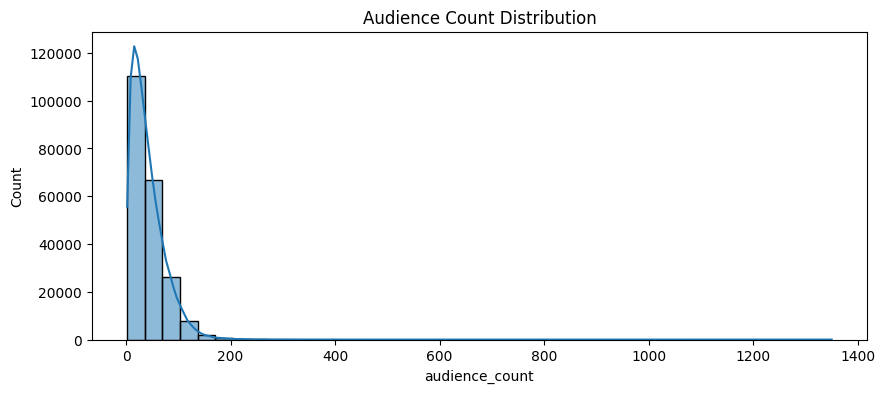

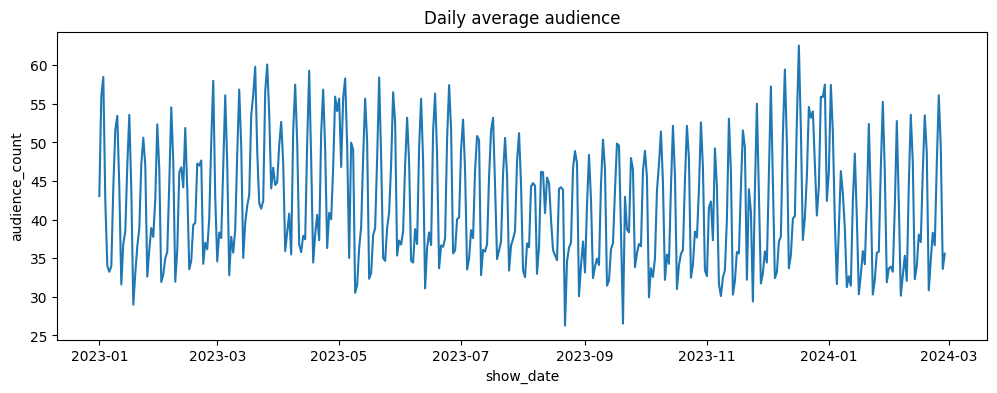

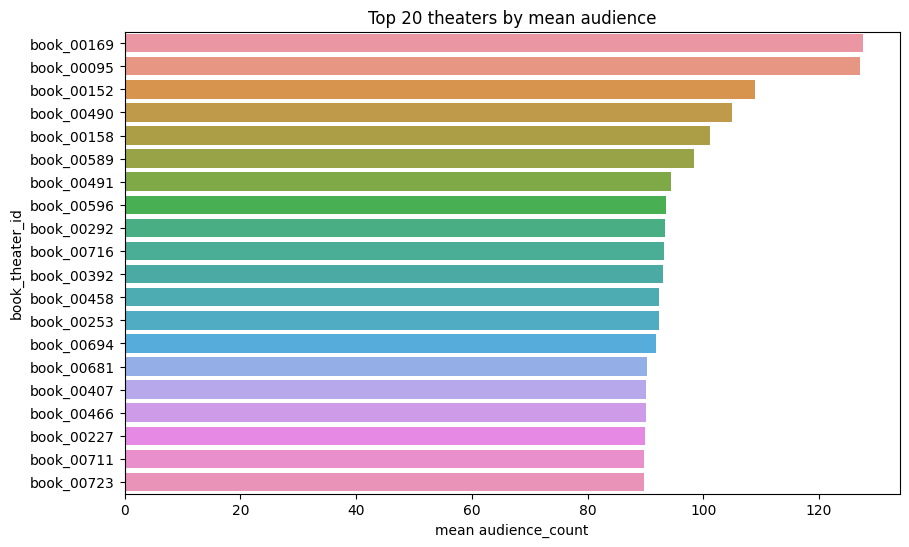

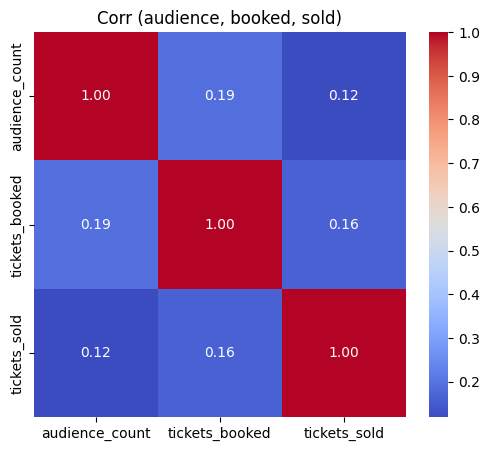

In [7]:
# CELL 6 - EDA plots
import matplotlib.dates as mdates
plt.figure(figsize=(10,4))
sns.histplot(df['audience_count'], bins=40, kde=True)
plt.title("Audience Count Distribution")
plt.xlabel("audience_count")
plt.show()

plt.figure(figsize=(12,4))
daily = df.groupby('show_date')['audience_count'].mean().reset_index()
sns.lineplot(data=daily, x='show_date', y='audience_count')
plt.title("Daily average audience")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.show()

plt.figure(figsize=(10,6))
top = df.groupby('book_theater_id')['audience_count'].mean().sort_values(ascending=False).head(20)
sns.barplot(x=top.values, y=top.index)
plt.title("Top 20 theaters by mean audience")
plt.xlabel("mean audience_count")
plt.show()

plt.figure(figsize=(6,5))
corr = df[['audience_count','tickets_booked','tickets_sold']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Corr (audience, booked, sold)")
plt.show()


In [8]:
# CELL 7 - Feature engineering: date parts and lags/rolling means
df['dow'] = df['show_date'].dt.dayofweek
df['is_weekend'] = df['dow'].isin([5,6]).astype(int)
df['month'] = df['show_date'].dt.month
df['year'] = df['show_date'].dt.year

# create lags and rolling features per theater
for L in [1,3,7,14]:
    df[f'lag_{L}'] = df.groupby('book_theater_id')['audience_count'].shift(L)

df['roll_mean_3'] = df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(1).rolling(3).mean())
df['roll_mean_7'] = df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(1).rolling(7).mean())
df['roll_mean_14'] = df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(1).rolling(14).mean())

# fill NaNs from lags/rolls with 0 (this is safe and consistent with training earlier)
df.fillna(0, inplace=True)
print("Added lag/rolling features. Example columns:", [c for c in df.columns if c.startswith('lag_')][:6])


Added lag/rolling features. Example columns: ['lag_1', 'lag_3', 'lag_7', 'lag_14']


In [9]:
# CELL 8 - simple target encoding for theater_type/theater_area (statistical priors)
theater_type_mean = df.groupby('theater_type')['audience_count'].mean()
theater_area_mean = df.groupby('theater_area')['audience_count'].mean()
df['theater_type_mean'] = df['theater_type'].map(theater_type_mean).fillna(df['audience_count'].mean())
df['theater_area_mean'] = df['theater_area'].map(theater_area_mean).fillna(df['audience_count'].mean())

# features used for modeling
features = [
    'tickets_booked','tickets_sold','dow','is_weekend','month',
    'lag_1','lag_3','lag_7','lag_14',
    'roll_mean_3','roll_mean_7','roll_mean_14',
    'latitude','longitude','theater_type_mean','theater_area_mean'
]
target = 'audience_count'
print("num features:", len(features))


num features: 16


In [10]:
# CELL 9 - Time split (no leakage) using last 45 days as validation
cutoff = df['show_date'].max() - pd.Timedelta(days=45)
train = df[df['show_date'] <= cutoff].copy()
valid = df[df['show_date'] > cutoff].copy()

X_train, y_train = train[features], train[target]
X_valid, y_valid = valid[features], valid[target]

print("train rows:", len(X_train), "valid rows:", len(X_valid))


train rows: 182372 valid rows: 31674


In [11]:
# CELL 10 - Pipeline for Ridge (scale numerics, onehot small cats)
num_cols = ['tickets_booked','tickets_sold','latitude','longitude',
            'lag_1','lag_3','lag_7','lag_14','roll_mean_3','roll_mean_7','roll_mean_14']
cat_cols = ['dow','is_weekend','month']  # small-cardinality -> OHE ok

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), cat_cols)
], remainder='passthrough')

ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_pipe.fit(X_train, y_train)
pred_ridge = ridge_pipe.predict(X_valid)
print("Ridge MAE:", mean_absolute_error(y_valid, pred_ridge), "RMSE:", mean_squared_error(y_valid, pred_ridge, squared=False), "R2:", r2_score(y_valid, pred_ridge))


Ridge MAE: 15.038392823906005 RMSE: 22.840754274201842 R2: 0.4500301684820577


In [12]:
# CELL 11 - Random Forest baseline
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_valid)
print("RF MAE:", mean_absolute_error(y_valid, pred_rf), "RMSE:", mean_squared_error(y_valid, pred_rf, squared=False), "R2:", r2_score(y_valid, pred_rf))


RF MAE: 14.145985005748077 RMSE: 20.63578973024259 R2: 0.5510890781886555


In [13]:
# CELL 12 - LightGBM training with early stopping (params that gave ~0.32 LB)
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, reference=lgb_train)

params = {
    'objective':'regression',
    'metric':'l1',
    'learning_rate':0.03,
    'num_leaves': 63,
    'max_depth':10,
    'feature_fraction':0.85,
    'bagging_fraction':0.85,
    'bagging_freq':5,
    'min_data_in_leaf':40,
    'seed':42,
    'verbose': -1
}

print("Training LightGBM...")
bst = lgb.train(params,
                lgb_train,
                num_boost_round=2000,
                valid_sets=[lgb_valid],
                callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
               )

pred_lgb = bst.predict(X_valid, num_iteration=bst.best_iteration)
print("LightGBM MAE:", mean_absolute_error(y_valid, pred_lgb), "RMSE:", mean_squared_error(y_valid, pred_lgb, squared=False), "R2:", r2_score(y_valid, pred_lgb))


Training LightGBM...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 14.1483
[400]	valid_0's l1: 14.0912
Early stopping, best iteration is:
[427]	valid_0's l1: 14.0888
LightGBM MAE: 14.088808546952793 RMSE: 20.443439599096926 R2: 0.5594188433560328


In [14]:
# CELL 13 - Compare models and select best by MAE
def stats(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true,y_pred),
        'RMSE': mean_squared_error(y_true,y_pred,squared=False),
        'R2': r2_score(y_true,y_pred)
    }

comp = pd.DataFrame({
    'Ridge': stats(y_valid, pred_ridge),
    'RandomForest': stats(y_valid, pred_rf),
    'LightGBM': stats(y_valid, pred_lgb)
}).T

print(comp.round(4))
best_model_name = comp['MAE'].idxmin()
print("Best model on validation by MAE:", best_model_name)


                  MAE     RMSE      R2
Ridge         15.0384  22.8408  0.4500
RandomForest  14.1460  20.6358  0.5511
LightGBM      14.0888  20.4434  0.5594
Best model on validation by MAE: LightGBM


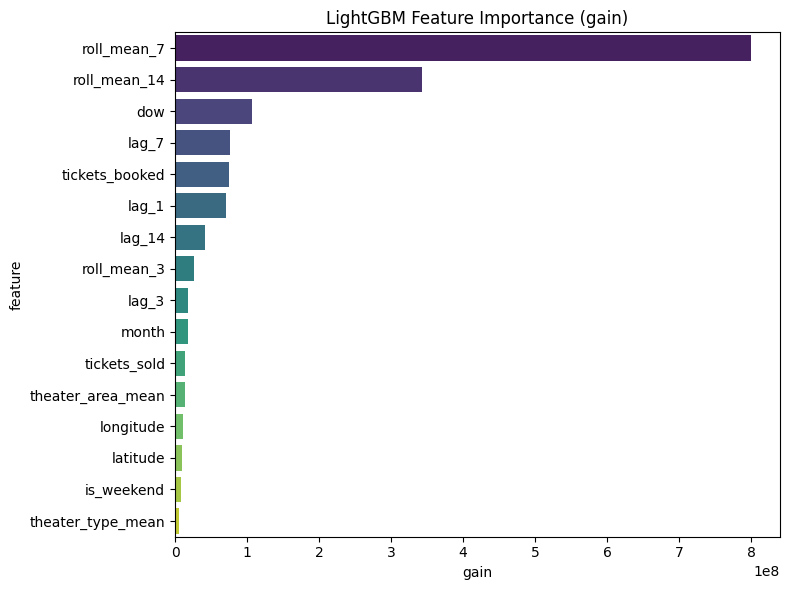

              feature          gain
10        roll_mean_7  7.999548e+08
11       roll_mean_14  3.433791e+08
2                 dow  1.065627e+08
7               lag_7  7.647531e+07
0      tickets_booked  7.540596e+07
5               lag_1  7.038106e+07
8              lag_14  4.202339e+07
9         roll_mean_3  2.701018e+07
6               lag_3  1.829656e+07
4               month  1.820549e+07
1        tickets_sold  1.368331e+07
15  theater_area_mean  1.323570e+07
13          longitude  1.110175e+07
12           latitude  9.805367e+06
3          is_weekend  8.290365e+06
14  theater_type_mean  5.070789e+06


In [15]:
# CELL 14 - feature importance from LightGBM (gain)
feature_pre_filter = False


imp = bst.feature_importance(importance_type='gain')
feat_names = bst.feature_name()
fi = pd.DataFrame({'feature':feat_names,'gain':imp}).sort_values('gain',ascending=False).head(20)
plt.figure(figsize=(8,6))
sns.barplot(x='gain', y='feature', data=fi, palette='viridis')
plt.title("LightGBM Feature Importance (gain)")
plt.tight_layout()
plt.show()
print(fi)


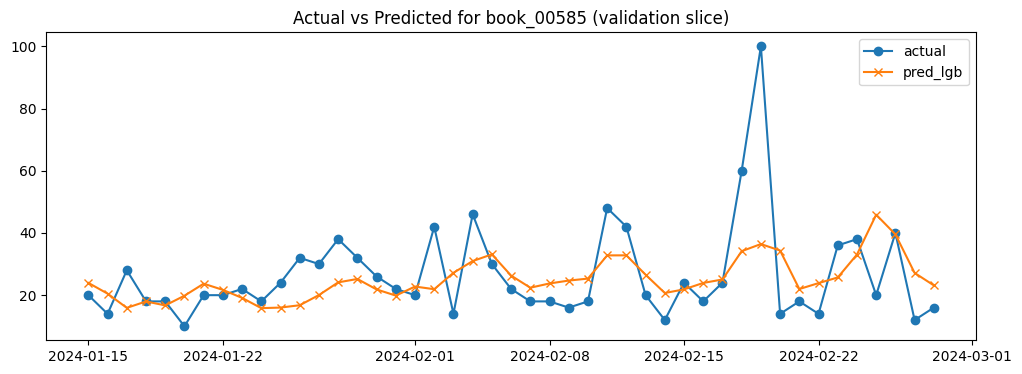

In [16]:
# CELL 15 - Visual check: sample theater actual vs predicted (validation)
valid_plot = valid.copy()
valid_plot['pred_lgb'] = pred_lgb

# pick a theater that appears in validation and has many rows; fallback to first if needed
cands = valid_plot['book_theater_id'].value_counts()
sample_th = cands.index[0] if len(cands)>0 else valid_plot['book_theater_id'].iloc[0]
subset = valid_plot[valid_plot['book_theater_id']==sample_th]

plt.figure(figsize=(12,4))
plt.plot(subset['show_date'], subset['audience_count'], label='actual', marker='o')
plt.plot(subset['show_date'], subset['pred_lgb'], label='pred_lgb', marker='x')
plt.title(f"Actual vs Predicted for {sample_th} (validation slice)")
plt.legend()
plt.show()


In [17]:
# CELL 17 - Refit LightGBM on full training data (train+valid) for final predictions
full_train = pd.concat([train, valid], axis=0).reset_index(drop=True)
X_full = full_train[features]
y_full = full_train[target]

dtrain_full = lgb.Dataset(X_full, label=y_full)
final_params = params.copy()  # update with best from CELL 16 if you ran it
final_bst = lgb.train(final_params, dtrain_full, num_boost_round=bst.best_iteration or 500)
print("Final model trained on full data. Best iterations used:", final_bst.num_trees())


Final model trained on full data. Best iterations used: 427


In [18]:
# CELL 18 - Build test feature frame from sample IDs
sample_sub = pd.read_csv(BASE + "sample_submission/sample_submission.csv")
sample_sub['book_theater_id'] = sample_sub['ID'].apply(lambda x: "_".join(x.split("_")[:2]))
sample_sub['show_date'] = pd.to_datetime(sample_sub['ID'].apply(lambda x: x.split("_")[-1]))

test = sample_sub.merge(book_theaters, on='book_theater_id', how='left')
test = test.merge(date_info, on='show_date', how='left')
test = test.merge(bn_daily, on=['book_theater_id','show_date'], how='left')
test = test.merge(cp_daily, on=['book_theater_id','show_date'], how='left')
test[['tickets_booked','tickets_sold']] = test[['tickets_booked','tickets_sold']].fillna(0)
test['dow'] = test['show_date'].dt.dayofweek
test['is_weekend'] = test['dow'].isin([5,6]).astype(int)
test['month'] = test['show_date'].dt.month
test['latitude'] = test['latitude'].fillna(df['latitude'].mean())
test['longitude'] = test['longitude'].fillna(df['longitude'].mean())
test.head(3)


,ID,audience_count,book_theater_id,show_date,theater_type,theater_area,latitude,longitude,day_of_week,tickets_booked,tickets_sold,dow,is_weekend,month
0,book_00001_2024-03-01,0,book_00001,2024-03-01,Drama,Area_002,23.00441,79.934515,Friday,0.0,0.0,4,0,3
1,book_00001_2024-03-02,0,book_00001,2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday,0.0,0.0,5,1,3
2,book_00001_2024-03-03,0,book_00001,2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday,0.0,0.0,6,1,3


In [19]:
# CELL 19 - Compute last 14 days per theater from df (training history)
hist = df.groupby('book_theater_id')['audience_count'].apply(lambda x: x.tail(14).tolist()).to_dict()

def get_last(arr, k):
    return arr[-k] if len(arr) >= k else 0

lag_rows = []
for _, row in test.iterrows():
    arr = hist.get(row['book_theater_id'], [0]*14)
    lag_rows.append([
        get_last(arr,1),
        get_last(arr,3),
        get_last(arr,7),
        get_last(arr,14),
        np.mean(arr[-3:]) if len(arr)>=3 else np.mean(arr),
        np.mean(arr[-7:]) if len(arr)>=7 else np.mean(arr),
        np.mean(arr[-14:]) if len(arr)>=14 else np.mean(arr)
    ])
lag_df = pd.DataFrame(lag_rows, columns=['lag_1','lag_3','lag_7','lag_14','roll_mean_3','roll_mean_7','roll_mean_14'])
test = pd.concat([test.reset_index(drop=True), lag_df.reset_index(drop=True)], axis=1)

# add target-encoding features
test['theater_type_mean'] = test['theater_type'].map(theater_type_mean).fillna(df['audience_count'].mean())
test['theater_area_mean'] = test['theater_area'].map(theater_area_mean).fillna(df['audience_count'].mean())

# ensure same feature order and fill NA
test_features = test[features].fillna(0)
print("test_features shape:", test_features.shape)


test_features shape: (38062, 16)


In [20]:
# CELL 20 - Predict and save submission using final_bst
pred_test = final_bst.predict(test_features, num_iteration=final_bst.best_iteration)
pred_test = np.clip(pred_test, 0, 200)  # safe bounds
pred_test = np.round(pred_test).astype(int)

submission = pd.DataFrame({'ID': sample_sub['ID'], 'audience_count': pred_test})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv — rows:", len(submission))
submission.head()


Saved submission.csv — rows: 38062


,ID,audience_count
0,book_00001_2024-03-01,32
1,book_00001_2024-03-02,38
2,book_00001_2024-03-03,43
3,book_00001_2024-03-04,38
4,book_00001_2024-03-06,32
